# ***Start***

### ***Import Libraries***

In [261]:
import pandas as pd

from mplsoccer import Pitch

import matplotlib.patches as mpatches

### ***Notebook Settings***

In [262]:
pd.set_option('display.max_columns', None)  # Show all columns
"""
pd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)
pd.set_option('display.max_colwidth', None) # Optional: expand the column width
pd.set_option('display.width', 200) # Optional: display width to prevent wrapping
"""

"\npd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)\npd.set_option('display.max_colwidth', None) # Optional: expand the column width\npd.set_option('display.width', 200) # Optional: display width to prevent wrapping\n"

### ***Import Data***

In [263]:
data = pd.read_csv("data/raw_data.csv")
data.head()

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner
0,80.8,51.6,False,SecondHalf,True,Center,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,79.3,24.2,False,SecondHalf,True,Center,True,True,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,80.0,59.5,False,SecondHalf,True,Center,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,89.8,55.6,False,SecondHalf,True,Center,NaN,NaN,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,84.9,56.2,False,SecondHalf,True,Center,NaN,True,True,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# ***Data Inspection***

In [264]:
data.shape

(8118, 25)

In [265]:
data.columns

Index(['x', 'y', 'is_goal', 'period', 'Assisted', 'Zone', 'IndividualPlay',
       'RegularPlay', 'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch',
       'Head', 'BigChance', 'SetPiece', 'Volley', 'FastBreak',
       'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass', 'DirectFreekick',
       'OwnGoal', 'OtherBodyPart', 'DirectCorner'],
      dtype='str')

In [266]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8118 entries, 0 to 8117
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   x                8118 non-null   float64
 1   y                8118 non-null   float64
 2   is_goal          8118 non-null   bool   
 3   period           8118 non-null   str    
 4   Assisted         6038 non-null   object 
 5   Zone             8118 non-null   str    
 6   IndividualPlay   2802 non-null   object 
 7   RegularPlay      5390 non-null   object 
 8   LeftFoot         2791 non-null   object 
 9   RightFoot        3994 non-null   object 
 10  FromCorner       1194 non-null   object 
 11  FirstTouch       3925 non-null   object 
 12  Head             1300 non-null   object 
 13  BigChance        1607 non-null   object 
 14  SetPiece         393 non-null    object 
 15  Volley           810 non-null    object 
 16  FastBreak        616 non-null    object 
 17  ThrowinSetPiece  188 non-

## ***Feature Values***

***Let's take a look at the features and their possible values...***

***"x, y, is_goal" are pretty self-explanatory so I can skip them***

In [267]:
unknown_data_columns1 = ['period', 'Assisted', 'Zone', 'IndividualPlay', 'RegularPlay', 'LeftFoot'] 
unknown_data_columns2 = ['RightFoot', 'FromCorner', 'FirstTouch', 'Head', 'BigChance', 'SetPiece']
unknown_data_columns3 = ['Volley', 'FastBreak', 'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass']
unknown_data_columns4 = ['DirectFreekick', 'OwnGoal', 'OtherBodyPart', 'DirectCorner']

In [268]:
for i in unknown_data_columns1:
    print(data[i].value_counts(), "\n")

period
SecondHalf    4347
FirstHalf     3771
Name: count, dtype: int64 

Assisted
True    6038
Name: count, dtype: int64 

Zone
Center    8047
Left        30
Right       23
Back        18
Name: count, dtype: int64 

IndividualPlay
True    2802
Name: count, dtype: int64 

RegularPlay
True    5390
Name: count, dtype: int64 

LeftFoot
True    2791
Name: count, dtype: int64 



In [269]:
for i in unknown_data_columns2:
    print(data[i].value_counts(), "\n")

RightFoot
True    3994
Name: count, dtype: int64 

FromCorner
True    1194
Name: count, dtype: int64 

FirstTouch
True    3925
Name: count, dtype: int64 

Head
True    1300
Name: count, dtype: int64 

BigChance
True    1607
Name: count, dtype: int64 

SetPiece
True    393
Name: count, dtype: int64 



In [270]:
for i in unknown_data_columns3:
    print(data[i].value_counts(), "\n")

Volley
True    810
Name: count, dtype: int64 

FastBreak
True    616
Name: count, dtype: int64 

ThrowinSetPiece
True    188
Name: count, dtype: int64 

Penalty
True    106
Name: count, dtype: int64 

OneOnOne
True    201
Name: count, dtype: int64 

KeyPass
True    58
Name: count, dtype: int64 



In [271]:
for i in unknown_data_columns4:
    print(data[i].value_counts(), "\n")

DirectFreekick
True    231
Name: count, dtype: int64 

OwnGoal
True    27
Name: count, dtype: int64 

OtherBodyPart
True    33
Name: count, dtype: int64 

DirectCorner
True    2
Name: count, dtype: int64 



***To-Do List***


***After looking at the features, I've decided to:***

***ONE HOT ENCODE the following [STR] features***

- Period
- Zone

***Convert all the remaining [OBJ] to [BOOL] and fill any missing values with FALSE***

## ***Shot Location***

### ***Shot Map***

In [272]:
pitch = Pitch(pitch_type='opta')

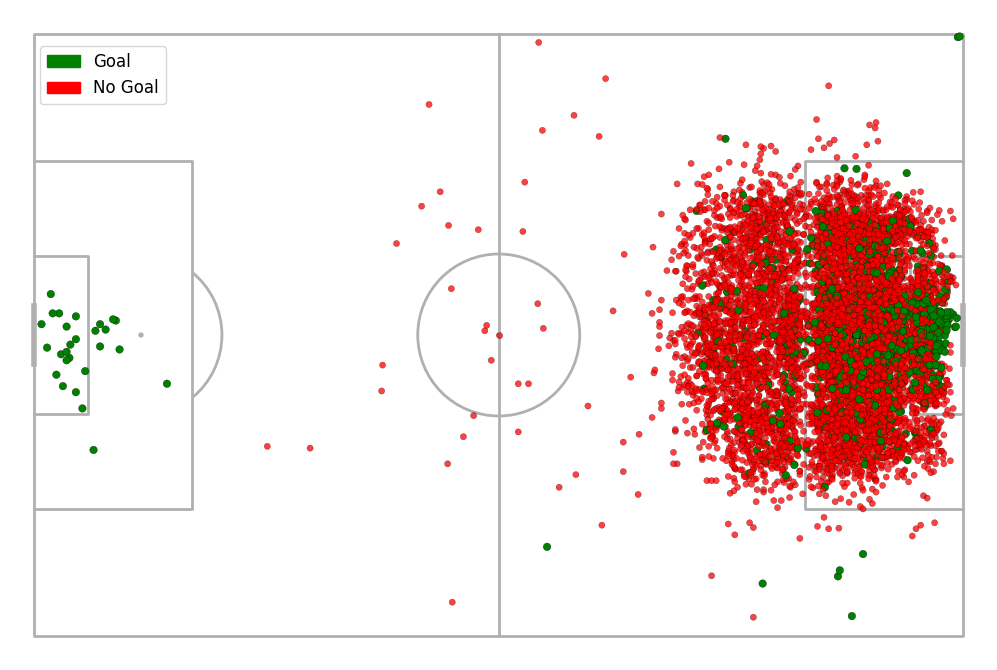

In [273]:
colors = [
    'green' if i==True else
    'red' if i==False else
    'black' for i in data['is_goal']
    ]

alpha = [
    0.75 if i==False else
    1 for i in data['is_goal']
    ]

size = [
    20 if i==False else
    30 for i in data['is_goal']
    ]

fig, ax = pitch.draw(figsize=(10.5*1, 6.8*1))

sc = pitch.scatter(
    data['x'], data['y'],                                       # Shot coordinates
    c=colors,                                                   # Distance for color
    edgecolors='black', linewidth=0.2, s=size, alpha=alpha,     # Point styling
    ax=ax
    )

legend_elements = [
    mpatches.Patch(color='green', label='Goal'),
    mpatches.Patch(color='red', label='No Goal'),
    ]

ax.legend(
    handles=legend_elements,
    loc='center',
    bbox_to_anchor=(0.095, 0.9),
    fontsize=12,   
    title_fontsize=16   
    )

### ***Why are there so many goals from the (0, 15) range despite being so far away?***

In [274]:
data[data.x<15].head()

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner
619,5.5,44.0,True,FirstHalf,NaN,Center,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN
749,3.5,51.4,True,FirstHalf,NaN,Center,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,True,NaN,NaN
1382,0.8,51.8,True,SecondHalf,NaN,Center,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN
1445,3.1,41.5,True,SecondHalf,NaN,Center,NaN,NaN,NaN,NaN,True,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN
1450,4.5,53.1,True,SecondHalf,NaN,Center,NaN,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN


***To-Do List***


***All these shots are OWN GOALS!!! Since Own Goals are unintentional and aren't even Shots, I feel they will provide no contribution in the context of xG, So I will remove all those datapoints and the OwnGoal feature...***

### ***Direct Corner Kick?***

In [275]:
data[data.DirectCorner==True]

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner
1696,99.4,99.5,True,SecondHalf,NaN,Left,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2293,99.6,99.6,True,FirstHalf,NaN,Left,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


***To-Do List***

***Direct corner goals are extremely rare events and typically occur due to significant goalkeeper error or unusual defensive positioning. As such, they represent statistical outliers, So I will remove all those datapoints and the DirectCorner feature...***

# ***Data Cleaning***

### ***To Do List***

- ***1- ONE HOT ENCODE "Period, Zone"***
- ***2- Fill the missing values with False in the remaining features and convert them to [Bool]***
- ***3- Remove datapoints having OwnGoal=True & The OwnGoal Feature***
- ***4- Remove datapoints having OwnGoal=True & The DirectCorner Feature***

### ***1- ONE HOT ENCODE "Period, Zone"***

In [276]:
data = pd.get_dummies(data, columns=['period', 'Zone'])
data.head()

,x,y,is_goal,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right
0,80.8,51.6,False,True,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True,False,False
1,79.3,24.2,False,True,True,True,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True,False,False
2,80.0,59.5,False,True,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True,False,False
3,89.8,55.6,False,True,NaN,NaN,NaN,NaN,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True,False,False
4,84.9,56.2,False,True,NaN,True,True,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,True,False,False


### ***2- Fill the missing values with False in the remaining features***

In [277]:
data.fillna(0, inplace=True)

data = data.astype({
    'is_goal': bool,
    'Assisted': bool,
    'IndividualPlay':bool,
    'RegularPlay':bool,
    'LeftFoot':bool,
    'RightFoot':bool,
    'FromCorner':bool,
    'FirstTouch':bool, 
    'Head':bool,
    'BigChance': bool,
    'SetPiece': bool,
    'Volley': bool,
    'FastBreak':bool,
    'ThrowinSetPiece':bool,
    'Penalty':bool, 
    'OneOnOne':bool,
    'KeyPass': bool,
    'DirectFreekick': bool,
    'OwnGoal': bool,
    'OtherBodyPart': bool,
    'DirectCorner': bool
})

data.head()

,x,y,is_goal,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right
0,80.8,51.6,False,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,79.3,24.2,False,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
2,80.0,59.5,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
3,89.8,55.6,False,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
4,84.9,56.2,False,True,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False


In [278]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8118 entries, 0 to 8117
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   x                  8118 non-null   float64
 1   y                  8118 non-null   float64
 2   is_goal            8118 non-null   bool   
 3   Assisted           8118 non-null   bool   
 4   IndividualPlay     8118 non-null   bool   
 5   RegularPlay        8118 non-null   bool   
 6   LeftFoot           8118 non-null   bool   
 7   RightFoot          8118 non-null   bool   
 8   FromCorner         8118 non-null   bool   
 9   FirstTouch         8118 non-null   bool   
 10  Head               8118 non-null   bool   
 11  BigChance          8118 non-null   bool   
 12  SetPiece           8118 non-null   bool   
 13  Volley             8118 non-null   bool   
 14  FastBreak          8118 non-null   bool   
 15  ThrowinSetPiece    8118 non-null   bool   
 16  Penalty            8118 non-null   

### ***3- Remove datapoints having OwnGoal=True & The OwnGoal Feature***

In [279]:
data = data[data.OwnGoal!=True]

data.OwnGoal.value_counts()

OwnGoal
False    8091
Name: count, dtype: int64

In [280]:
data.shape

(8091, 29)

In [281]:
data = data.drop(columns=["OwnGoal"])
data.shape

(8091, 28)

### ***4- Remove datapoints having OwnGoal=True & The DirectCorner Feature***

In [282]:
data = data[data.DirectCorner!=True]

data.DirectCorner.value_counts()

DirectCorner
False    8089
Name: count, dtype: int64

In [283]:
data.shape

(8089, 28)

In [284]:
data = data.drop(columns=["DirectCorner"])
data.shape

(8089, 27)

# ***Save Data***

In [285]:
is_goal = data['is_goal']
data.drop(columns='is_goal', inplace=True)
data['is_goal'] = is_goal

In [286]:
data.head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,is_goal
0,80.8,51.6,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
1,79.3,24.2,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
2,80.0,59.5,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
3,89.8,55.6,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False
4,84.9,56.2,True,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False


In [287]:
data.to_excel("data/clean_data.xlsx", index=False)